In [1]:
import sys
import os

# 1. Fix module imports
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 2. Fix file paths by changing the working directory
# We check if we are currently in the 'notebooks' folder to avoid stepping back too far if you run this cell twice.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir('..')
    
print(f"System path includes: {parent_dir}")
print(f"Current working directory is: {os.getcwd()}")

from src import (
    load_raw,
    get_prices_returns_volume,
    get_returns_long,
    get_volume_long,
    get_metadata,
    process_universe_etfs,
    load_prices_etf,
    download_prices_etf,
    get_returns_etf,
    get_returns_long_etf,
    compute_sector_correlation_matrix,
    compute_correlation_distribution,
    run_full_strategy,
    run_full_strategy_pca,
    plot_correlation_heatmap,
    plot_correlation_histogram,
    plot_performance, 
    run_pca_parameter_sweep
)

System path includes: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA
Current working directory is: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA


In [2]:
# ------------------------------------------------------------------------------
# 1. DATA INGESTION & PIPELINE
# ------------------------------------------------------------------------------
# Load local raw data (respecting the offline requirement)
raw = load_raw()
prices, returns, volume = get_prices_returns_volume(raw)

returns_long = get_returns_long(returns)
volume_long = get_volume_long(volume)

# Build the long-format panel
panel = returns_long.merge(volume_long, on=["date", "ticker"], how="left")

# ------------------------------------------------------------------------------
# 2. METADATA & ETF MAPPING
# ------------------------------------------------------------------------------
# get_metadata evaluates the local returns matrix and merges it with the local universe_metadata.csv
metadata_raw = get_metadata(returns)

# Execute ETF mapping
metadata, etfs, t2e, e2t = process_universe_etfs()

# Try to load local ETF data first. Only download if it doesn't exist.
try:
    prices_etf = load_prices_etf()
except FileNotFoundError:
    print("Local ETF prices not found. Falling back to yfinance download...")
    prices_etf = download_prices_etf(etfs)

returns_etf = get_returns_etf(prices_etf)
returns_long_etf = get_returns_long_etf(returns_etf)



Loading local data from data/raw/raw_data.csv...
Original data shape: (1258, 500)
Raw data loading complete.
Returns calculated. Shape: (1257, 100)
Price data saved to data/raw/prices.csv
Returns data saved to data/raw/returns.csv
Volume data saved to data/raw/volume.csv
Returns data saved to data/raw/returns_long.csv in long-format
Volume data saved to data/raw/volume_long.csv in long-format
Local metadata found. Updating statistical metrics without network calls.
Metadata saved to data/raw/universe_metadata.csv
Loading metadata from data/raw/universe_metadata.csv...
Successfully added 'etf' column and updated data/raw/universe_metadata.csv
Identified 11 unique sector ETFs: ['XLK', 'XLY', 'XLC', 'XLU', 'XLF', 'XLV', 'XLP', 'XLI', 'XLB', 'XLRE', 'XLE']
Loading local data from data/raw/prices_etf.csv...
Original data shape: (1258, 11)
Raw ETF data loading complete.
Returns calculated. Shape: (1257, 11)
ETF returns data saved to data/raw/returns_etf.csv
ETF returns data saved to data/raw

Filtering universe for full coverage and sorting by sector...
Kept 98 highly liquid, full-coverage stocks.
Generating heatmap...
Heatmap saved to data/results/correlation_heatmap.png


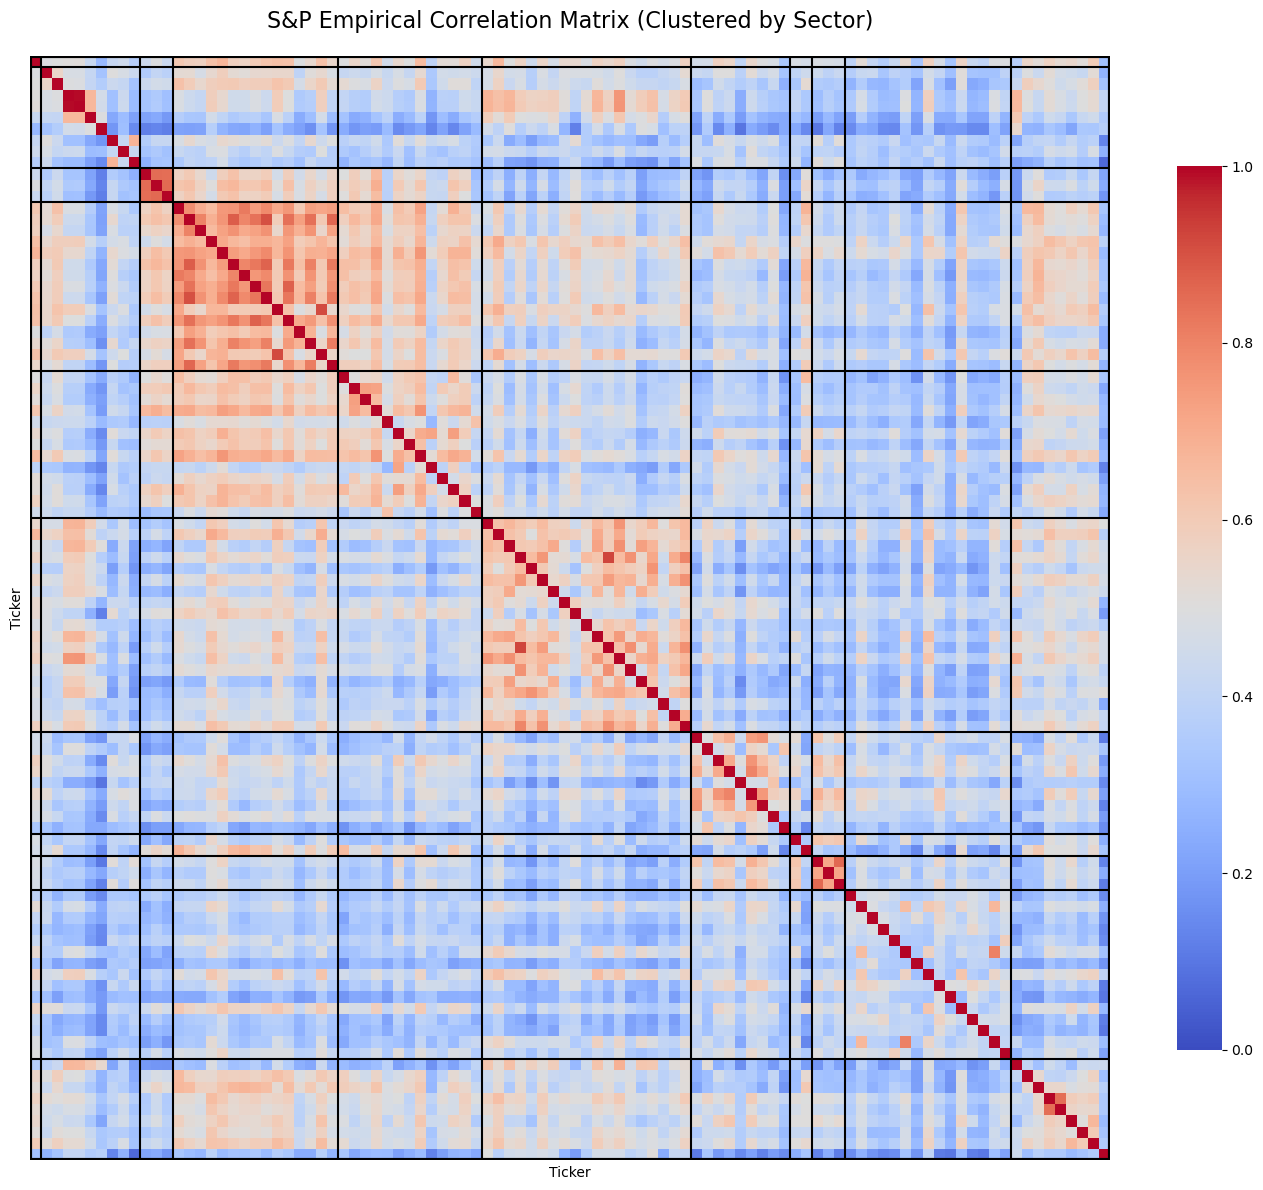

Generating distribution histogram...
Histogram saved to data/results/correlation_histogram.png


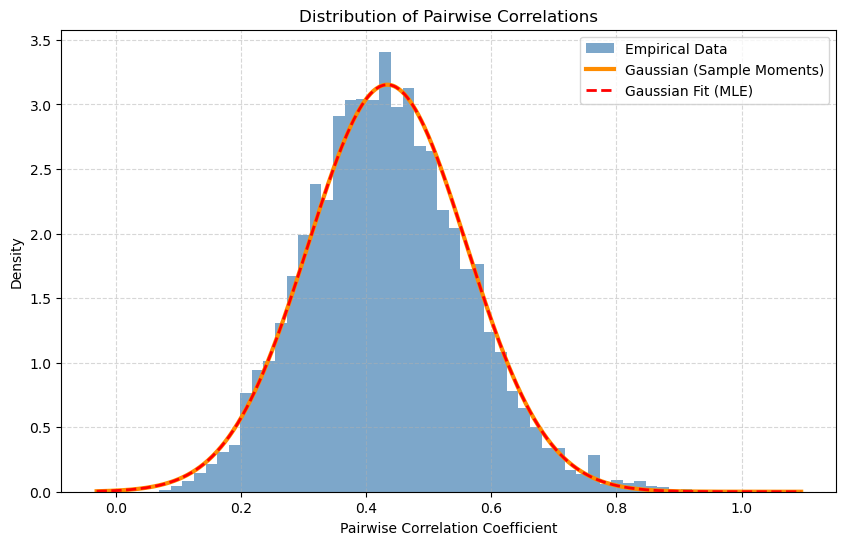

In [3]:
# ------------------------------------------------------------------------------
# 3. MATHEMATICAL ANALYSIS & VISUALIZATION
# ------------------------------------------------------------------------------
# Compute Correlation Matrix and Boundaries
corr_matrix, ordered_tickers, boundaries = compute_sector_correlation_matrix(returns, metadata)

# Plot Heatmap
plot_correlation_heatmap(
    corr_matrix, 
    ordered_tickers, 
    boundaries, 
    save_path="data/results/correlation_heatmap.png"
)

# Compute Distribution Moments and Gaussian Fit
corr_dist, stats_dict = compute_correlation_distribution(corr_matrix)

# Plot Histogram
plot_correlation_histogram(
    corr_dist, 
    stats_dict, 
    save_path="data/results/correlation_histogram.png"
)



Starting ETF Walk-Forward Simulation (1 param combinations)...
[Testing Phase] Executing blindly on 2020-04-03 to 2020-05-04
[Testing Phase] Executing blindly on 2020-05-05 to 2020-06-03
[Testing Phase] Executing blindly on 2020-06-04 to 2020-07-02
[Testing Phase] Executing blindly on 2020-07-06 to 2020-08-03
[Testing Phase] Executing blindly on 2020-08-04 to 2020-09-01
[Testing Phase] Executing blindly on 2020-09-02 to 2020-10-01
[Testing Phase] Executing blindly on 2020-10-02 to 2020-10-30
[Testing Phase] Executing blindly on 2020-11-02 to 2020-12-01
[Testing Phase] Executing blindly on 2020-12-02 to 2020-12-31
[Testing Phase] Executing blindly on 2021-01-04 to 2021-02-02
[Testing Phase] Executing blindly on 2021-02-03 to 2021-03-04
[Testing Phase] Executing blindly on 2021-03-05 to 2021-04-05
[Testing Phase] Executing blindly on 2021-04-06 to 2021-05-04
[Testing Phase] Executing blindly on 2021-05-05 to 2021-06-03
[Testing Phase] Executing blindly on 2021-06-04 to 2021-07-02
[Testin

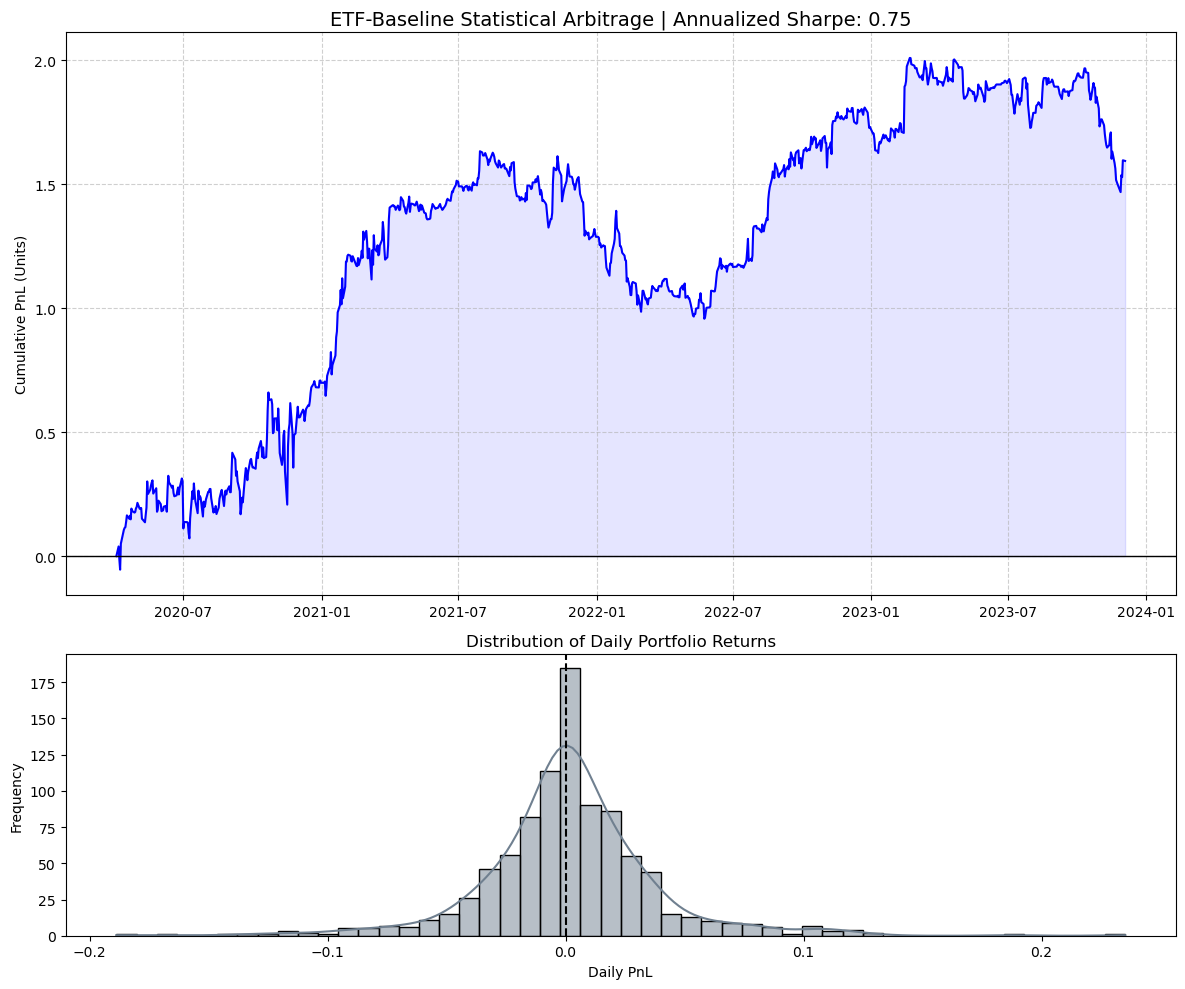

Starting Walk-Forward Optimization (12 param combinations)...

[Validation Phase] Tuning on 2020-01-03 to 2020-04-02
Selected Best Params: {'num_factors': 5, 'entry_threshold': 1.5, 'exit_threshold': 0.75, 'adf_p_threshold': 0.05, 'avg_window': 60} (Val Sharpe: -0.43)
[Testing Phase] Executing blindly on 2020-04-03 to 2020-05-04

[Validation Phase] Tuning on 2020-02-04 to 2020-05-04
Selected Best Params: {'num_factors': 10, 'entry_threshold': 1.5, 'exit_threshold': 0.5, 'adf_p_threshold': 0.05, 'avg_window': 60} (Val Sharpe: 3.99)
[Testing Phase] Executing blindly on 2020-05-05 to 2020-06-03

[Validation Phase] Tuning on 2020-03-05 to 2020-06-03
Selected Best Params: {'num_factors': 10, 'entry_threshold': 1.25, 'exit_threshold': 0.75, 'adf_p_threshold': 0.05, 'avg_window': 60} (Val Sharpe: 1.37)
[Testing Phase] Executing blindly on 2020-06-04 to 2020-07-02

[Validation Phase] Tuning on 2020-04-03 to 2020-07-02
Selected Best Params: {'num_factors': 10, 'entry_threshold': 1.5, 'exit_thre

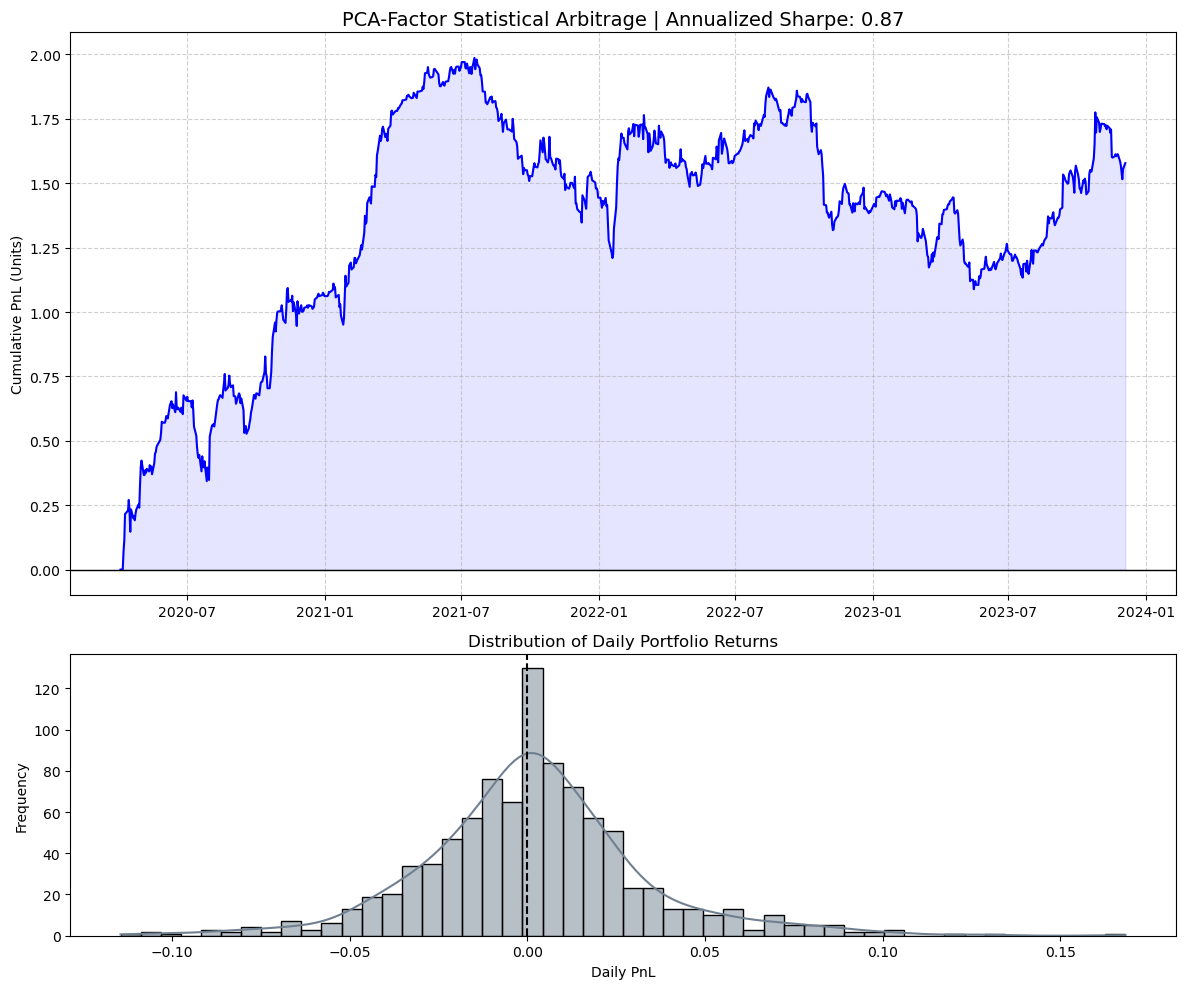

In [4]:
# ------------------------------------------------------------------------------
# 4. STRATEGY SIMULATIONS
# ------------------------------------------------------------------------------


# To run a static baseline (no tuning):
etf_param_grid = {
    'entry_threshold': [1.25],  # Z-score required to open a pair trade
    'exit_threshold': [0.50],   # Z-score target to flatten the position
    'adf_p_threshold': [0.05],  # Stricter values (e.g., 0.01) enforce higher mean-reversion certainty
    'avg_window': [60]          # Moving average days for the volume dampener
}

etf_oos_returns = run_full_strategy(
    returns, 
    volume, 
    returns_etf, 
    t2e, 
    # --- Tunable Parameters ---
    param_grid=etf_param_grid,
    train_days=252,             # Lookback window for OU calibration
    test_days=21,               # Out-of-sample trading window before recalibrating
)

plot_performance(
    etf_oos_returns, 
    model_name="ETF-Baseline", 
    save_path="data/results/etf_performance.png"
)


# Advanced: PCA Multi-Factor Statistical Arbitrage
pca_param_grid = {
    'num_factors': [5, 8, 10],          # Number of principal components to hedge against (e.g., 5, 8, 10, 12)
    'entry_threshold': [1.25, 1.50],    # Z-score required to open a pair trade
    'exit_threshold': [0.50, 0.75],     # Z-score target to flatten the position
    'adf_p_threshold': [0.05],          # Stricter values (e.g., 0.01) enforce higher mean-reversion certainty
    'avg_window': [60]                  # Moving average days for the volume dampener
}

pca_oos_returns = run_full_strategy_pca(
    returns, 
    volume,
    # --- Tunable Parameters ---
    param_grid=pca_param_grid,
    train_days=252,          # Lookback window for PCA and OU calibration
    val_days=63,             # Lookback window for hyperparameter tuning
    test_days=21,            # Out-of-sample trading window before recalibrating
)

plot_performance(
    pca_oos_returns, 
    model_name="PCA-Factor", 
    save_path="data/results/pca_performance.png"
)